(38, 7)
segment                    str
metric                     str
value_2024_eur_millions    str
value_2025_eur_millions    str
change_absolute            str
change_pct                 str
notes                      str
dtype: object
                   segment       metric value_2024_eur_millions  \
count                   38           38                      38   
unique                   5           20                      37   
top     Consolidated Group  Net Revenue                     234   
freq                    17            4                       2   

       value_2025_eur_millions change_absolute change_pct  \
count                       38              38         33   
unique                      36              34         30   
top                       1315              -2      -0.9%   
freq                         2               4          3   

                                        notes  
count                                      25  
unique                 

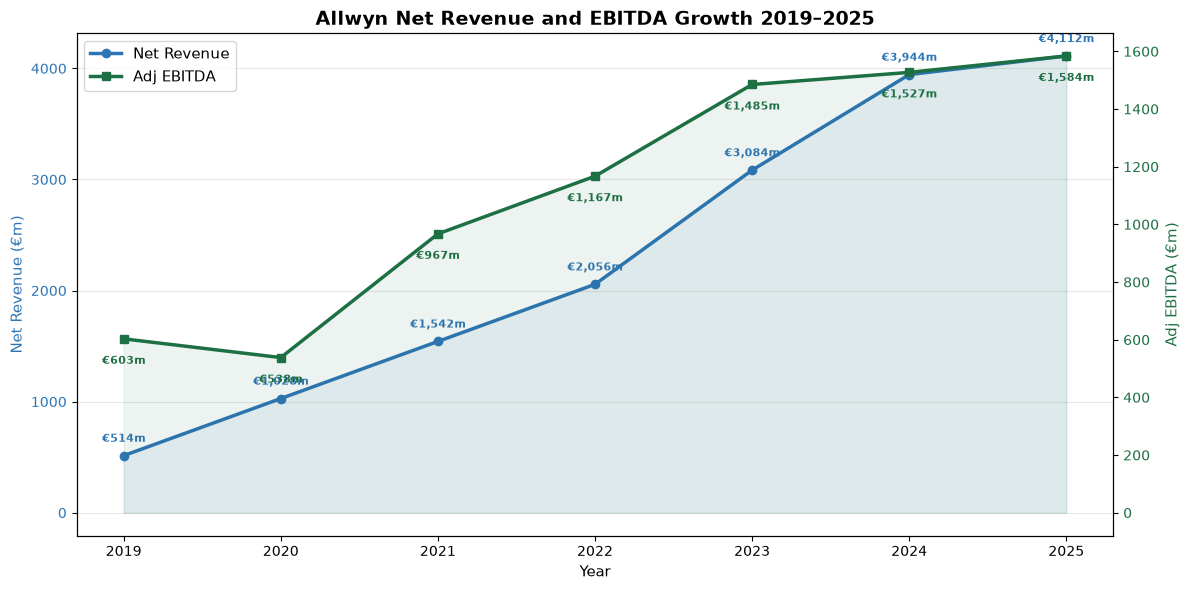

              segment                       metric value_2024_eur_millions  \
0  Continental Europe                Total Revenue                    4452   
1  Continental Europe                  Net Revenue                    2841   
2  Continental Europe              Adjusted EBITDA                    1287   
3  Continental Europe     Adjusted EBITDA Margin %                   45.3%   
4  Continental Europe                        CAPEX                      70   
5  Continental Europe  Adjusted EBITDA minus CAPEX                    1217   
6       North America                Total Revenue                     234   
7       North America                  Net Revenue                     234   
8       North America              Adjusted EBITDA                      45   
9       North America     Adjusted EBITDA Margin %                   19.2%   

  value_2025_eur_millions change_absolute change_pct  \
0                    4710             258       5.8%   
1                    2960    

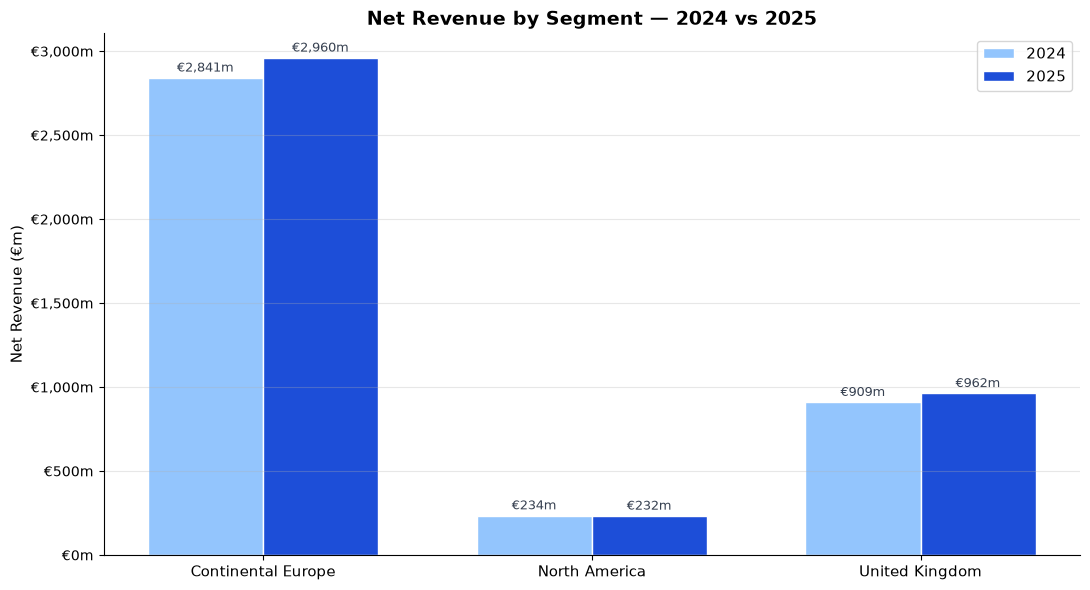

✅ Saved: chart_segment_comparison.png
               segment  value_2024  value_2025
3   Continental Europe        45.3        44.4
9        North America        19.2        18.1
15      United Kingdom         3.9         3.5


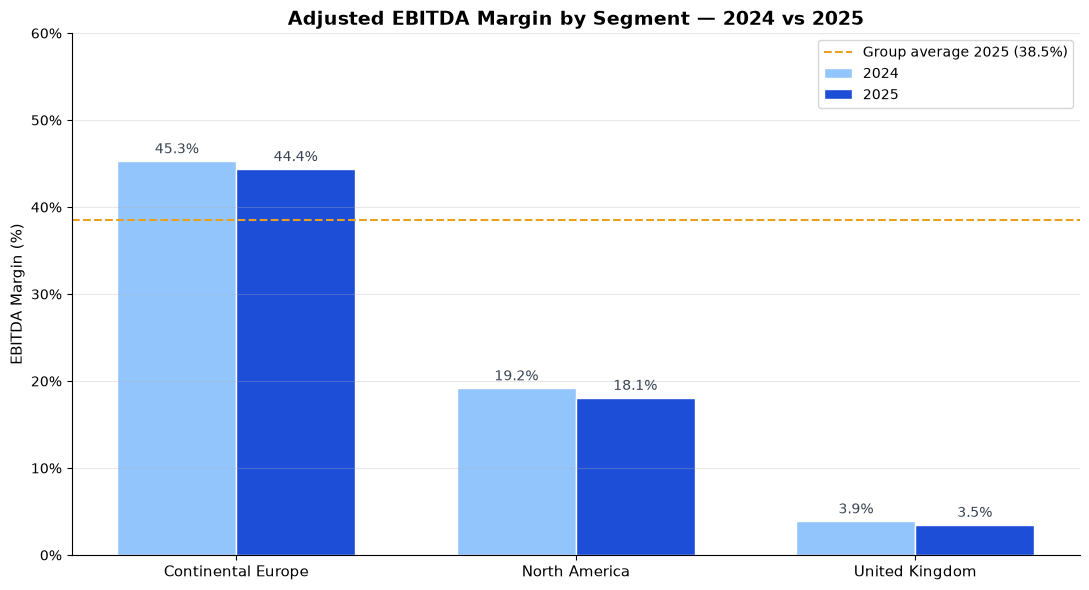

✅ Saved: chart_ebitda_margins.png
               segment  value_2024  value_2025  change  pct_share
2   Continental Europe        1287        1315      28       94.5
8        North America          45          42      -3        3.0
14      United Kingdom          35          34      -1        2.4


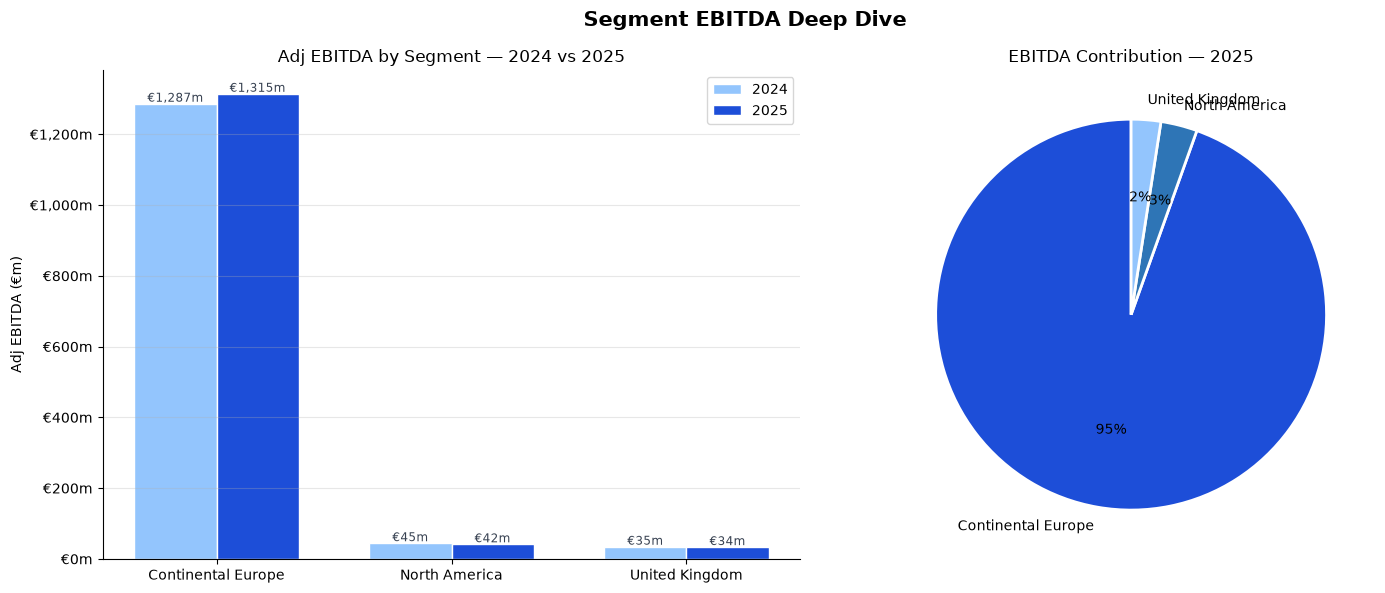

               product  ngr_2024  ngr_2025  change  change_pct
0              Lottery    2042.0    2129.0    87.0         4.3
6       Sports Betting     556.0     562.0     6.0         1.1
9              iGaming     445.0     496.0    51.0        11.5
11    VLTs and Casinos     538.0     566.0    28.0         5.2
13  Non-gaming Revenue     363.0     359.0    -4.0        -1.1


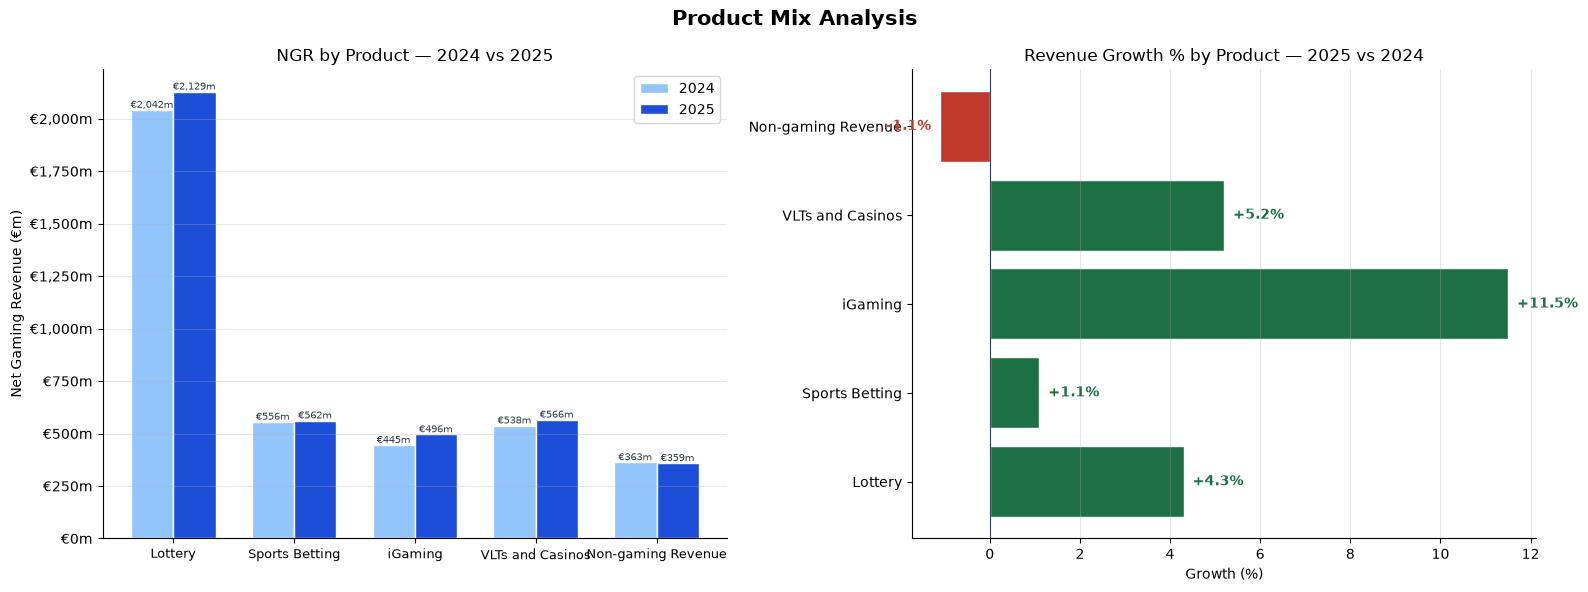

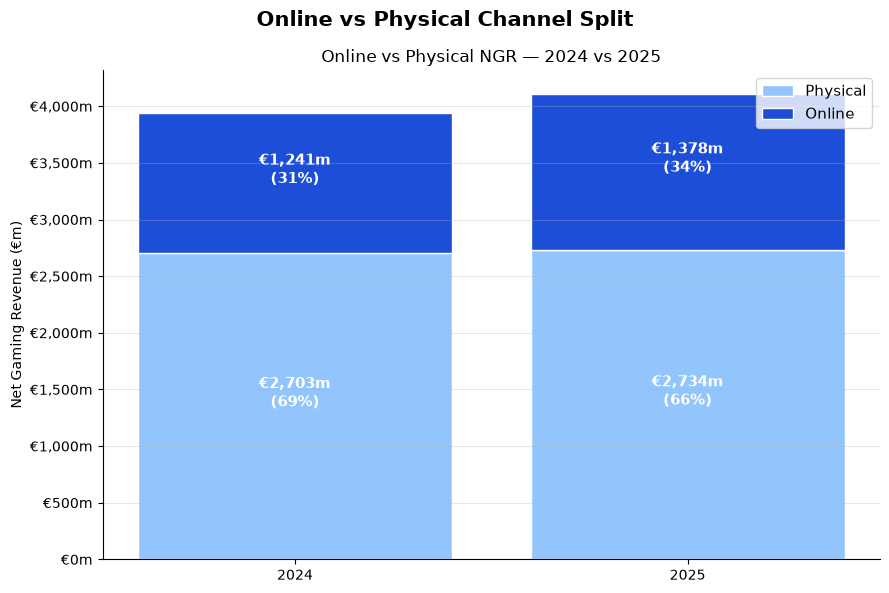

✅ Saved: chart_product_mix.png and chart_online_vs_physical.png
               segment  m_2024  m_2025  change
3   Continental Europe    45.3    44.4    -0.9
9        North America    19.2    18.1    -1.1
15      United Kingdom     3.9     3.5    -0.4
29  Consolidated Group    38.7    38.5    -0.2


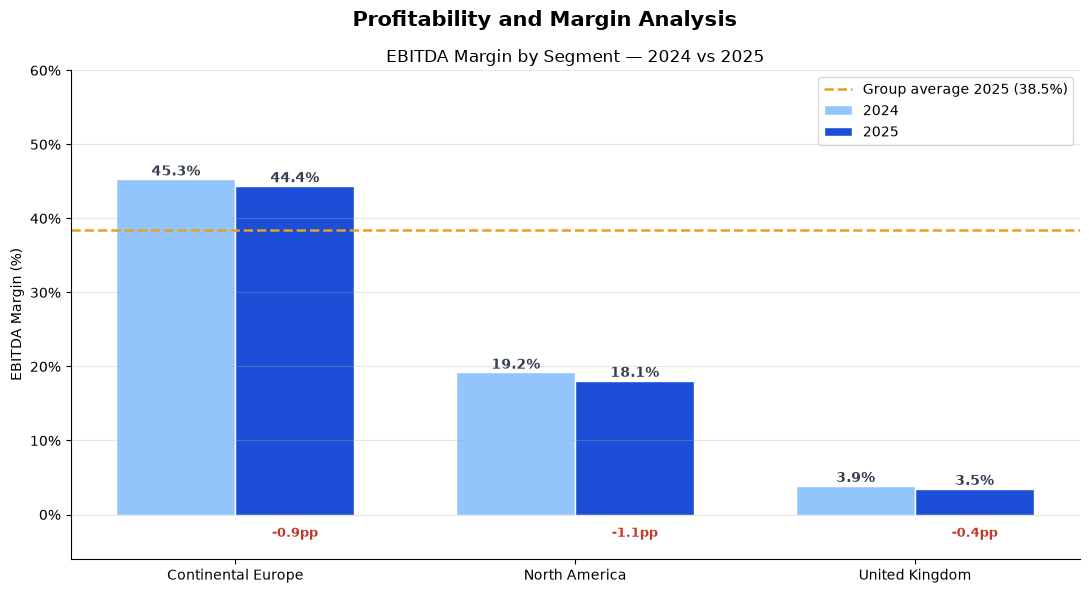

✅ Saved: chart_margins.png
                               metric  val_2024  val_2025  change
0                Cash from Operations      1050      1034     -16
1                  Net Operating Cash       529       513     -16
2                  Net Investing Cash      -551      -729    -178
3                  Net Financing Cash      -321       269     590
4  Free Cash Flow\n(Adj EBITDA-CAPEX)      1271      1330      59


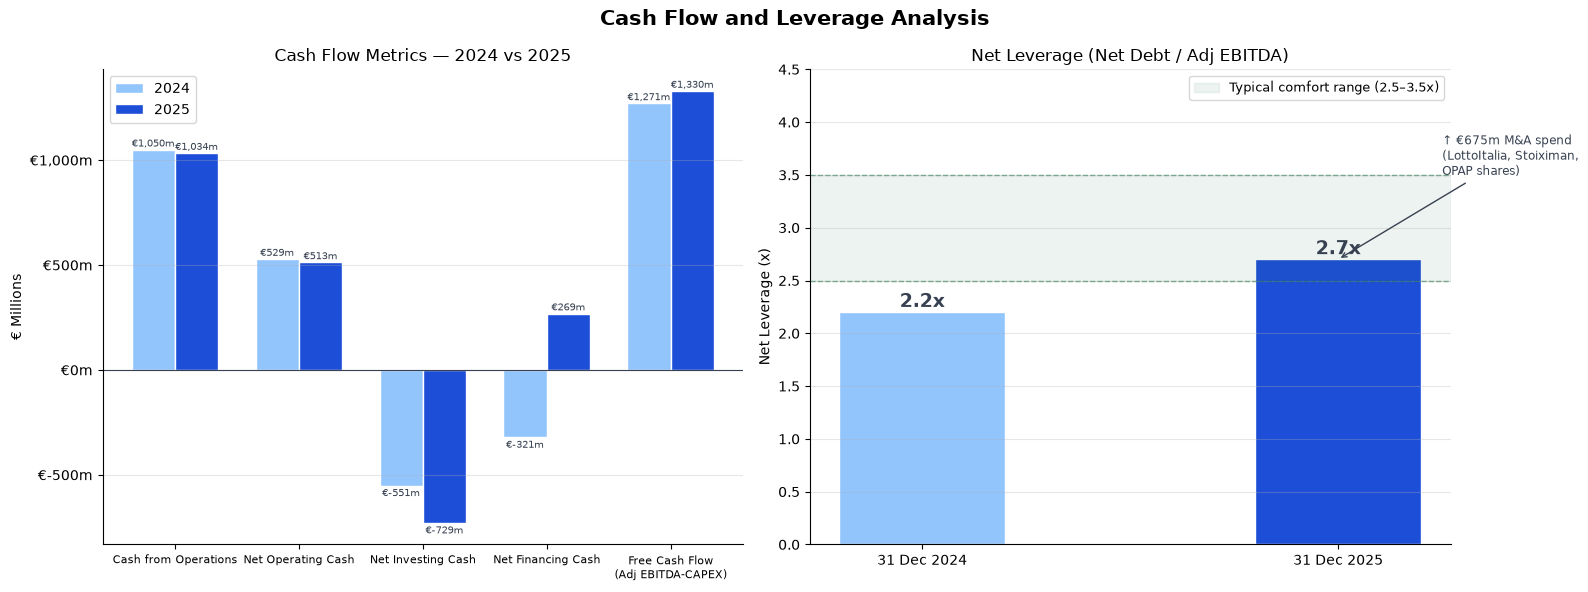

✅ Saved: chart_cashflow_leverage.png


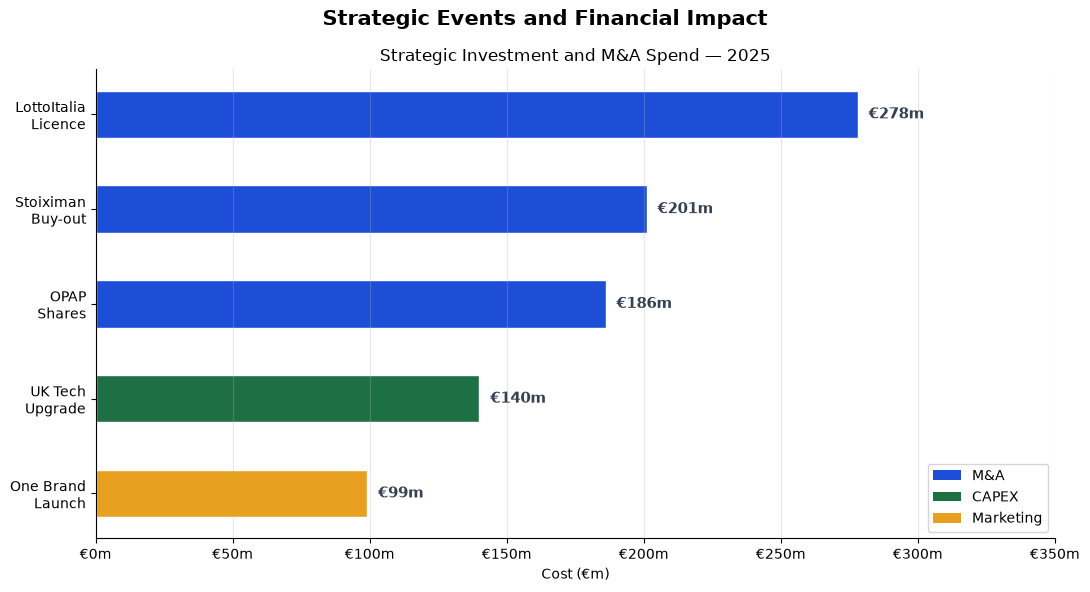

✅ Saved: chart_ma_spend.png  |  Total spend: €904m


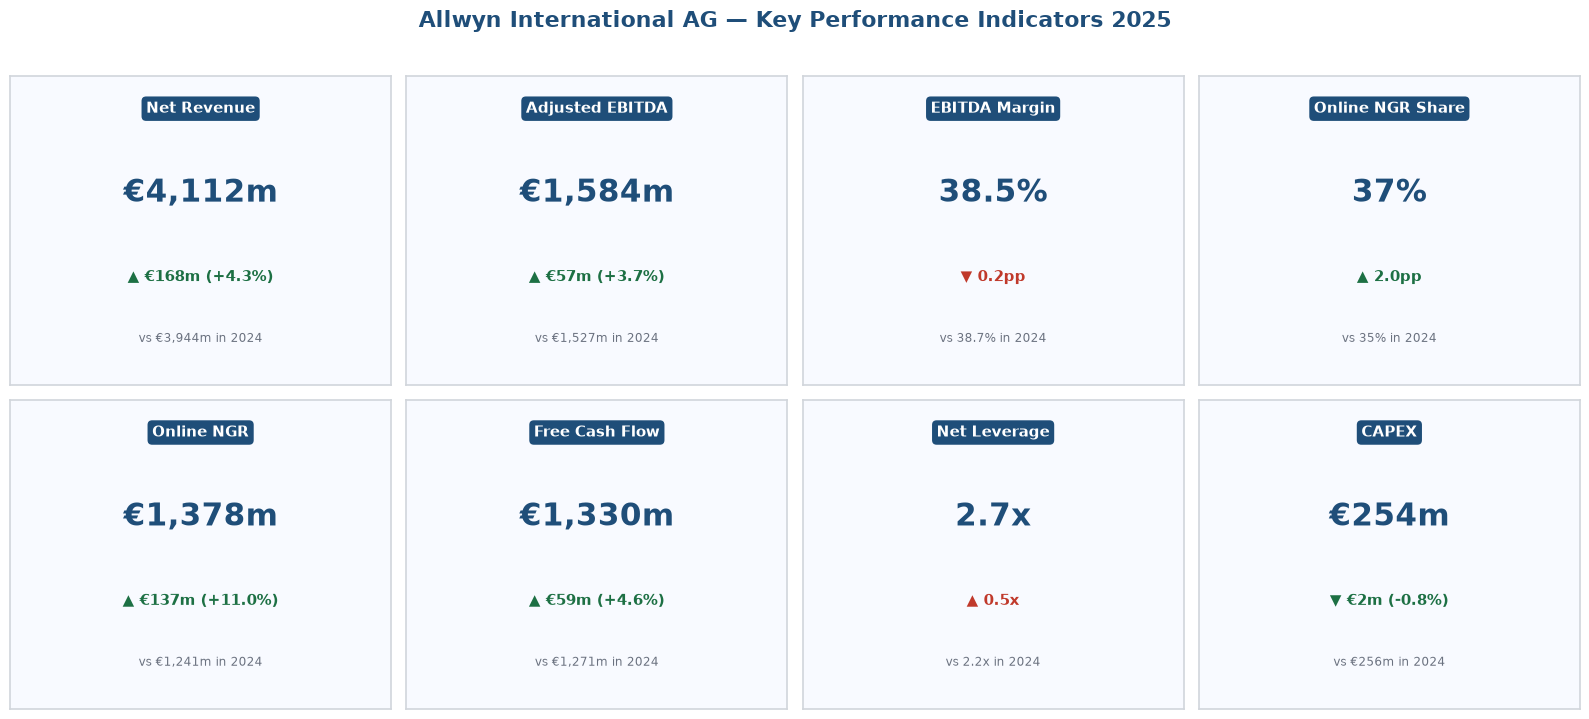

✅ Saved: chart_kpi_summary.png


In [12]:
# ============================================================
# Allwyn International AG — Financial Analysis 2025
# Author  : Christos Stoicheios
# Data    : csv/01_financial_performance_by_segment.csv
#           cvs/02_revenue_by_product_and_channel
#           csv/03_historical_track_record_2019_2025.csv
# Steps   : 1-EDA | 2-Revenue Trend | 3-Segment | 4-EBITDA
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ============================================================
# Step 1 — Load and Explore the Data (EDA)
# ============================================================

df = pd.read_csv("csv/01_financial_performance_by_segment.csv")

print(df.shape)
print(df.dtypes)
print((df.describe()))
print(df.isnull().sum())

# ============================================================
# Step 2 — Revenue Trend Analysis (Time Serie)
# ============================================================

df_hist = pd.read_csv("csv/03_historical_track_record_2019_2025.csv")
df_hist = df_hist[df_hist["year"].apply(lambda x: str(x).isdigit())].copy()
df_hist["year"] = df_hist["year"].astype(int)
df_hist["net_revenue_eur_millions"] = pd.to_numeric(df_hist["net_revenue_eur_millions"])
df_hist["adjusted_ebitda_eur_millions"] = pd.to_numeric(df_hist["adjusted_ebitda_eur_millions"])

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.plot(df_hist["year"], df_hist["net_revenue_eur_millions"],
         marker="o", linewidth=2.5, color="#2E75B6", label="Net Revenue")
ax1.fill_between(df_hist["year"], df_hist["net_revenue_eur_millions"],
                 alpha=0.08, color="#2E75B6")

ax2.plot(df_hist["year"], df_hist["adjusted_ebitda_eur_millions"],
         marker="s", linewidth=2.5, color="#1D7044", label="Adj EBITDA")
ax2.fill_between(df_hist["year"], df_hist["adjusted_ebitda_eur_millions"],
                 alpha=0.08, color="#1D7044")


for _, row in df_hist.iterrows():
    ax1.annotate(f"€{row['net_revenue_eur_millions']:,.0f}m",
                 xy=(row["year"], row["net_revenue_eur_millions"]),
                 xytext=(0, 10), textcoords="offset points",
                 ha="center", fontsize=8, color="#2E75B6", fontweight="bold")

for _, row in df_hist.iterrows():
    ax2.annotate(f"€{row['adjusted_ebitda_eur_millions']:,.0f}m",
                 xy=(row["year"], row["adjusted_ebitda_eur_millions"]),
                 xytext=(0, -18), textcoords="offset points",
                 ha="center", fontsize=8, color="#1D7044", fontweight="bold")

ax1.set_title("Allwyn Net Revenue and EBITDA Growth 2019–2025",
              fontsize=14, fontweight="bold")
ax1.set_xlabel("Year", fontsize=11)
ax1.set_ylabel("Net Revenue (€m)", fontsize=11, color="#2E75B6")
ax2.set_ylabel("Adj EBITDA (€m)", fontsize=11, color="#1D7044")
ax1.tick_params(axis="y", labelcolor="#2E75B6")
ax2.tick_params(axis="y", labelcolor="#1D7044")
ax1.set_xticks(df_hist["year"])
ax1.grid(axis="y", alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc="upper left")

plt.tight_layout()
plt.savefig("chart_revenue_trend.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# Step 3 — Segment Performance Comparison
# ============================================================

print(df.head(10))
print(df["segment"].unique())
print(df["metric"].unique())

net_rev = df[df["metric"] == "Net Revenue"].copy()

segments_to_show = ["Continental Europe", "North America", "United Kingdom"]
net_rev = net_rev[net_rev["segment"].isin(segments_to_show)]

net_rev["value_2024_eur_millions"] = pd.to_numeric(net_rev["value_2024_eur_millions"])
net_rev["value_2025_eur_millions"] = pd.to_numeric(net_rev["value_2025_eur_millions"])

print(net_rev[["segment", "value_2024_eur_millions", "value_2025_eur_millions"]])

x = range(len(net_rev))          # 0, 1, 2  — one position per segment
width = 0.35                      # how wide each bar is

fig, ax = plt.subplots(figsize=(11, 6))

bars_2024 = ax.bar([i - width/2 for i in x],
                   net_rev["value_2024_eur_millions"],
                   width=width, color="#93C5FD", label="2024", edgecolor="white")

bars_2025 = ax.bar([i + width/2 for i in x],
                   net_rev["value_2025_eur_millions"],
                   width=width, color="#1D4ED8", label="2025", edgecolor="white")

for bar in bars_2024:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 20,
            f"€{bar.get_height():,.0f}m",
            ha="center", va="bottom", fontsize=9, color="#374151")

for bar in bars_2025:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 20,
            f"€{bar.get_height():,.0f}m",
            ha="center", va="bottom", fontsize=9, color="#374151")

ax.set_title("Net Revenue by Segment — 2024 vs 2025", fontsize=14, fontweight="bold")
ax.set_ylabel("Net Revenue (€m)", fontsize=11)
ax.set_xticks(list(x))
ax.set_xticklabels(net_rev["segment"].tolist(), fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:,.0f}m"))
ax.legend(fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("chart_segment_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: chart_segment_comparison.png")

#---Part2---
ebitda = df[df["metric"] == "Adjusted EBITDA Margin %"].copy()

ebitda = ebitda[ebitda["segment"].isin(segments_to_show)]

ebitda["value_2024"] = (
    ebitda["value_2024_eur_millions"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.replace("pp", "", regex=False)
    .str.strip()
)
ebitda["value_2025"] = (
    ebitda["value_2025_eur_millions"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.replace("pp", "", regex=False)
    .str.strip()
)

ebitda["value_2024"] = pd.to_numeric(ebitda["value_2024"], errors="coerce")
ebitda["value_2025"] = pd.to_numeric(ebitda["value_2025"], errors="coerce")

print(ebitda[["segment", "value_2024", "value_2025"]])

x = range(len(ebitda))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars_2024 = ax.bar([i - width/2 for i in x],
                   ebitda["value_2024"],
                   width=width, color="#93C5FD", label="2024", edgecolor="white")

bars_2025 = ax.bar([i + width/2 for i in x],
                   ebitda["value_2025"],
                   width=width, color="#1D4ED8", label="2025", edgecolor="white")

for bar in bars_2024:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom", fontsize=10, color="#374151")

for bar in bars_2025:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom", fontsize=10, color="#374151")

group_avg_2025 = 38.5
ax.axhline(y=group_avg_2025, color="#E8A020", linewidth=1.5,
           linestyle="--", label=f"Group average 2025 ({group_avg_2025}%)")


ax.set_title("Adjusted EBITDA Margin by Segment — 2024 vs 2025",
             fontsize=14, fontweight="bold")
ax.set_ylabel("EBITDA Margin (%)", fontsize=11)
ax.set_xticks(list(x))
ax.set_xticklabels(ebitda["segment"].tolist(), fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_ylim(0, 60)    
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("chart_ebitda_margins.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: chart_ebitda_margins.png")

# ============================================================
# Step 4 — EBITDA Contribution by Segment
# ============================================================

ebitda_seg = (
    df[df["metric"] == "Adjusted EBITDA"]
    .copy()
    .assign(
        value_2024=lambda x: pd.to_numeric(x["value_2024_eur_millions"], errors="coerce"),
        value_2025=lambda x: pd.to_numeric(x["value_2025_eur_millions"], errors="coerce"),
    )
    .loc[lambda x: x["segment"].isin([
        "Continental Europe", "Betano (equity investee)",
        "North America", "United Kingdom"
    ])]
    .assign(
        change=lambda x: x["value_2025"] - x["value_2024"],
        pct_share=lambda x: (x["value_2025"] / x["value_2025"].sum() * 100).round(1),
        segment=lambda x: x["segment"].str.replace("Betano (equity investee)", "Betano", regex=False)
    )
)

print(ebitda_seg[["segment", "value_2024", "value_2025", "change", "pct_share"]])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
x, w = range(len(ebitda_seg)), 0.35

for bars, col, label, offset in [
    (ebitda_seg["value_2024"], "#93C5FD", "2024", -w/2),
    (ebitda_seg["value_2025"], "#1D4ED8", "2025", +w/2),
]:
    b = ax1.bar([i + offset for i in x], bars, width=w,
                color=col, label=label, edgecolor="white")
    for bar in b:
        ax1.text(bar.get_x() + w/2, bar.get_height() + 5,
                 f"€{bar.get_height():,.0f}m",
                 ha="center", fontsize=8.5, color="#374151")

ax1.set(title="Adj EBITDA by Segment — 2024 vs 2025",
        ylabel="Adj EBITDA (€m)", xticks=list(x),
        xticklabels=ebitda_seg["segment"].tolist())
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:,.0f}m"))
ax1.legend(); ax1.grid(axis="y", alpha=0.3)
[ax1.spines[s].set_visible(False) for s in ["top", "right"]]

ax2.pie(ebitda_seg["value_2025"], labels=ebitda_seg["segment"],
        autopct="%1.0f%%", startangle=90,
        colors=["#1D4ED8","#2E75B6","#93C5FD","#BFDBFE"],
        wedgeprops={"edgecolor": "white", "linewidth": 2})
ax2.set_title("EBITDA Contribution — 2025")

plt.suptitle("Segment EBITDA Deep Dive", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("chart_ebitda_contribution.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# Step 5 — Product and Channel Mix Analysis
# ============================================================

df2 = pd.read_csv("csv/02_revenue_by_product_and_channel.csv")

products = ["Lottery", "Sports Betting", "iGaming", "VLTs and Casinos", "Non-gaming Revenue"]

prod = (
    df2[df2["product"].isin(products) & (df2["segment"] == "Consolidated")]
    .copy()
    .assign(
        ngr_2024=lambda x: pd.to_numeric(x["value_2024_eur_millions"], errors="coerce"),
        ngr_2025=lambda x: pd.to_numeric(x["value_2025_eur_millions"], errors="coerce"),
    )
    .drop_duplicates(subset="product")
)

prod["change"]     = prod["ngr_2025"] - prod["ngr_2024"]
prod["change_pct"] = ((prod["change"] / prod["ngr_2024"]) * 100).round(1)

print(prod[["product", "ngr_2024", "ngr_2025", "change", "change_pct"]])

# ── Chart A: NGR by Product 2024 vs 2025 ──
x, w = range(len(prod)), 0.35
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for vals, col, label, offset in [
    (prod["ngr_2024"], "#93C5FD", "2024", -w/2),
    (prod["ngr_2025"], "#1D4ED8", "2025", +w/2),
]:
    b = ax1.bar([i + offset for i in x], vals, width=w,
                color=col, label=label, edgecolor="white")
    for bar in b:
        if bar.get_height() > 0:
            ax1.text(bar.get_x() + w/2, bar.get_height() + 10,
                     f"€{bar.get_height():,.0f}m",
                     ha="center", fontsize=7.5, color="#374151")

ax1.set(title="NGR by Product — 2024 vs 2025",
        ylabel="Net Gaming Revenue (€m)",
        xticks=list(x), xticklabels=prod["product"].tolist())
ax1.tick_params(axis="x", labelsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:,.0f}m"))
ax1.legend(); ax1.grid(axis="y", alpha=0.3)
[ax1.spines[s].set_visible(False) for s in ["top", "right"]]

# ── Chart B: Growth % by product ──
colors = ["#1D7044" if v >= 0 else "#C0392B" for v in prod["change_pct"]]
ax2.barh(prod["product"], prod["change_pct"], color=colors, edgecolor="white")

for i, (val, product) in enumerate(zip(prod["change_pct"], prod["product"])):
    ax2.text(val + 0.2 if val >= 0 else val - 0.2, i,
             f"{val:+.1f}%", va="center",
             ha="left" if val >= 0 else "right",
             fontsize=10, fontweight="bold",
             color="#1D7044" if val >= 0 else "#C0392B")

ax2.axvline(x=0, color="#374151", linewidth=0.8)
ax2.set(title="Revenue Growth % by Product — 2025 vs 2024",
        xlabel="Growth (%)")
ax2.grid(axis="x", alpha=0.3)
[ax2.spines[s].set_visible(False) for s in ["top", "right"]]

plt.suptitle("Product Mix Analysis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("chart_product_mix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Chart C: Online vs Physical — stacked bars ──
online   = [1241, 1378]
physical = [3944 - 1241, 4112 - 1378]   # total NGR minus online
years    = ["2024", "2025"]

fig, ax = plt.subplots(figsize=(9, 6))

b1 = ax.bar(years, physical, color="#93C5FD", label="Physical", edgecolor="white")
b2 = ax.bar(years, online, bottom=physical, color="#1D4ED8", label="Online", edgecolor="white")

for bar, val, on in zip(b1, physical, online):
    ax.text(bar.get_x() + bar.get_width()/2, val/2,
            f"€{val:,.0f}m\n({val/(val+on)*100:.0f}%)",
            ha="center", fontsize=11, color="white", fontweight="bold")

for bar, val, on in zip(b2, online, physical):
    ax.text(bar.get_x() + bar.get_width()/2, on + val/2,
            f"€{val:,.0f}m\n({val/(val+on)*100:.0f}%)",
            ha="center", fontsize=11, color="white", fontweight="bold")

ax.set(title="Online vs Physical NGR — 2024 vs 2025",
       ylabel="Net Gaming Revenue (€m)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:,.0f}m"))
ax.legend(fontsize=11); ax.grid(axis="y", alpha=0.3)
[ax.spines[s].set_visible(False) for s in ["top", "right"]]

plt.suptitle("Online vs Physical Channel Split",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("chart_online_vs_physical.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: chart_product_mix.png and chart_online_vs_physical.png")

# ============================================================
# Step 6 — Profitability and Margin Analysis
# ============================================================

segments = ["Continental Europe", "North America", "United Kingdom", "Consolidated Group"]

margins = (
    df[df["metric"] == "Adjusted EBITDA Margin %"]
    .copy()
    .loc[lambda x: x["segment"].isin(segments)]
    .assign(
        m_2024=lambda x: pd.to_numeric(
            x["value_2024_eur_millions"].astype(str).str.replace("%","").str.replace("pp","").str.strip(),
            errors="coerce"),
        m_2025=lambda x: pd.to_numeric(
            x["value_2025_eur_millions"].astype(str).str.replace("%","").str.replace("pp","").str.strip(),
            errors="coerce"),
    )
    .assign(change=lambda x: x["m_2025"] - x["m_2024"])
)

print(margins[["segment", "m_2024", "m_2025", "change"]])

# Split Consolidated Group out — shown as a reference line, not a bar
group_avg = margins[margins["segment"] == "Consolidated Group"]["m_2025"].values[0]
seg = margins[margins["segment"] != "Consolidated Group"].copy()

fig, ax = plt.subplots(figsize=(11, 6))

x = range(len(seg))
w = 0.35

for vals, col, label, offset in [
    (seg["m_2024"], "#93C5FD", "2024", -w/2),
    (seg["m_2025"], "#1D4ED8", "2025", +w/2),
]:
    b = ax.bar([i + offset for i in x], vals, width=w,
               color=col, label=label, edgecolor="white")
    for bar in b:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{bar.get_height():.1f}%",
                ha="center", fontsize=10, color="#374151", fontweight="bold")

# Group average reference line
ax.axhline(y=group_avg, color="#E8A020", linewidth=1.8, linestyle="--",
           label=f"Group average 2025 ({group_avg}%)")

# Change labels below each 2025 bar
for i, (_, row) in enumerate(seg.iterrows()):
    color = "#1D7044" if row["change"] >= 0 else "#C0392B"
    ax.text(i + w/2, -3, f"{row['change']:+.1f}pp",
            ha="center", fontsize=9, color=color, fontweight="bold")

ax.set(title="EBITDA Margin by Segment — 2024 vs 2025",
       ylabel="EBITDA Margin (%)",
       xticks=list(x), xticklabels=seg["segment"].tolist(),
       ylim=(-6, 60))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)
[ax.spines[s].set_visible(False) for s in ["top", "right"]]

plt.suptitle("Profitability and Margin Analysis",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("chart_margins.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: chart_margins.png")

# ============================================================
# Step 7 — Cash Flow and Leverage Analysis
# ============================================================

# Data from the Annual Report (not in CSV — hardcoded from Word doc)
cashflow = pd.DataFrame({
    "metric": [
        "Cash from Operations",
        "Net Operating Cash",
        "Net Investing Cash",
        "Net Financing Cash",
        "Free Cash Flow\n(Adj EBITDA-CAPEX)"
    ],
    "val_2024": [1050, 529, -551, -321, 1271],
    "val_2025": [1034, 513, -729,  269, 1330],
})
cashflow["change"] = cashflow["val_2025"] - cashflow["val_2024"]

print(cashflow[["metric", "val_2024", "val_2025", "change"]])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: Cash flow metrics grouped bars ─────────────────────
x, w = range(len(cashflow)), 0.35

for vals, col, label, offset in [
    (cashflow["val_2024"], "#93C5FD", "2024", -w/2),
    (cashflow["val_2025"], "#1D4ED8", "2025", +w/2),
]:
    b = ax1.bar([i + offset for i in x], vals, width=w,
                color=col, label=label, edgecolor="white")
    for bar in b:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2,
                 h + 15 if h >= 0 else h - 50,
                 f"€{h:,.0f}m",
                 ha="center", fontsize=7.5, color="#374151")

ax1.axhline(y=0, color="#374151", linewidth=0.8)
ax1.set(title="Cash Flow Metrics — 2024 vs 2025",
        ylabel="€ Millions",
        xticks=list(x), xticklabels=cashflow["metric"].tolist())
ax1.tick_params(axis="x", labelsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:,.0f}m"))
ax1.legend(fontsize=10); ax1.grid(axis="y", alpha=0.3)
[ax1.spines[s].set_visible(False) for s in ["top", "right"]]

# ── Right: Net leverage waterfall 2024 → 2025 ────────────────
leverage   = [2.2, 2.7]
lever_labs = ["31 Dec 2024", "31 Dec 2025"]
bar_colors = ["#93C5FD", "#1D4ED8"]

bars = ax2.bar(lever_labs, leverage, color=bar_colors,
               edgecolor="white", width=0.4)

for bar, val in zip(bars, leverage):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.05,
             f"{val}x", ha="center", fontsize=14,
             fontweight="bold", color="#374151")

# Comfort zone band
ax2.axhspan(2.5, 3.5, alpha=0.08, color="#1D7044",
            label="Typical comfort range (2.5–3.5x)")
ax2.axhline(y=2.5, color="#1D7044", linewidth=1,
            linestyle="--", alpha=0.5)
ax2.axhline(y=3.5, color="#1D7044", linewidth=1,
            linestyle="--", alpha=0.5)

ax2.set(title="Net Leverage (Net Debt / Adj EBITDA)",
        ylabel="Net Leverage (x)", ylim=(0, 4.5))
ax2.legend(fontsize=9); ax2.grid(axis="y", alpha=0.3)
[ax2.spines[s].set_visible(False) for s in ["top", "right"]]

# Annotation explaining the increase
ax2.annotate("↑ €675m M&A spend\n(LottoItalia, Stoiximan,\nOPAP shares)",
             xy=(1, 2.7), xytext=(1.25, 3.5),
             fontsize=8.5, color="#374151",
             arrowprops=dict(arrowstyle="->", color="#374151"))

plt.suptitle("Cash Flow and Leverage Analysis",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("chart_cashflow_leverage.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: chart_cashflow_leverage.png")

# ============================================================
# Step 8 — Strategic M&A and Investment Spend 2025
# ============================================================

ma = pd.DataFrame({
    "event": [
        "LottoItalia\nLicence",
        "Stoiximan\nBuy-out",
        "OPAP\nShares",
        "UK Tech\nUpgrade",
        "One Brand\nLaunch"
    ],
    "cost": [278, 201, 186, 140, 99],
    "category": ["M&A", "M&A", "M&A", "CAPEX", "Marketing"]
})

ma = ma.sort_values("cost", ascending=True)

# Colour by category
color_map  = {"M&A": "#1D4ED8", "CAPEX": "#1D7044", "Marketing": "#E8A020"}
bar_colors = [color_map[c] for c in ma["category"]]

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(ma["event"], ma["cost"],
               color=bar_colors, edgecolor="white", height=0.5)

# Value labels
for bar, val in zip(bars, ma["cost"]):
    ax.text(bar.get_width() + 4, bar.get_y() + bar.get_height()/2,
            f"€{val}m", va="center", fontsize=11,
            fontweight="bold", color="#374151")

# Total line
total = ma["cost"].sum()
ax.axvline(x=total/len(ma), color="#C0392B", linewidth=0,)  # invisible — just for legend spacing

# Legend manually
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#1D4ED8", label="M&A"),
    Patch(facecolor="#1D7044", label="CAPEX"),
    Patch(facecolor="#E8A020", label="Marketing"),
]
ax.legend(handles=legend_elements, fontsize=10, loc="lower right")


ax.set(title="Strategic Investment and M&A Spend — 2025",
       xlabel="Cost (€m)", xlim=(0, 350))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v:.0f}m"))
ax.grid(axis="x", alpha=0.3)
[ax.spines[s].set_visible(False) for s in ["top", "right"]]

plt.suptitle("Strategic Events and Financial Impact",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("chart_ma_spend.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved: chart_ma_spend.png  |  Total spend: €{total}m")

# ============================================================
# Step 9 — KPI Summary Dashboard
# ============================================================

kpis = [
    # (Label, 2024 value, 2025 value, unit, higher=better)
    ("Net Revenue",        3944,   4112,  "€m",  True),
    ("Adjusted EBITDA",    1527,   1584,  "€m",  True),
    ("EBITDA Margin",      38.7,   38.5,  "%",   True),
    ("Online NGR Share",   35,     37,    "%",   True),
    ("Online NGR",         1241,   1378,  "€m",  True),
    ("Free Cash Flow",     1271,   1330,  "€m",  True),
    ("Net Leverage",       2.2,    2.7,   "x",   False),
    ("CAPEX",              256,    254,   "€m",  False),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, (label, val_2024, val_2025, unit, higher_is_better) in zip(axes, kpis):
    change     = val_2025 - val_2024
    change_pct = (change / val_2024) * 100
    improved   = (change > 0) == higher_is_better
    arrow      = "▲" if change > 0 else "▼"
    color      = "#1D7044" if improved else "#C0392B"

    # Background
    ax.set_facecolor("#F8FAFF")

    # 2025 value — big and central
    if unit == "€m":
        val_str = f"€{val_2025:,.0f}m"
    elif unit == "%":
        val_str = f"{val_2025}%"
    else:
        val_str = f"{val_2025}x"

    ax.text(0.5, 0.62, val_str,
            transform=ax.transAxes, ha="center", va="center",
            fontsize=22, fontweight="bold", color="#1F4E79")

    # Change arrow + value
    if unit == "€m":
        change_str = f"{arrow} €{abs(change):,.0f}m ({change_pct:+.1f}%)"
    elif unit == "%":
        change_str = f"{arrow} {abs(change):.1f}pp"
    else:
        change_str = f"{arrow} {abs(change):.1f}x"

    ax.text(0.5, 0.35, change_str,
            transform=ax.transAxes, ha="center", va="center",
            fontsize=11, fontweight="bold", color=color)

    # 2024 comparison
    if unit == "€m":
        prev_str = f"vs €{val_2024:,.0f}m in 2024"
    elif unit == "%":
        prev_str = f"vs {val_2024}% in 2024"
    else:
        prev_str = f"vs {val_2024}x in 2024"

    ax.text(0.5, 0.15, prev_str,
            transform=ax.transAxes, ha="center", va="center",
            fontsize=8.5, color="#6B7280")

    # Title bar at top
    ax.text(0.5, 0.92, label,
            transform=ax.transAxes, ha="center", va="top",
            fontsize=11, fontweight="bold", color="white",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#1F4E79",
                      edgecolor="none", alpha=1))

    # Border
    for spine in ax.spines.values():
        spine.set_edgecolor("#D1D5DB")
        spine.set_linewidth(1.2)

    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("Allwyn International AG — Key Performance Indicators 2025",
             fontsize=16, fontweight="bold", color="#1F4E79", y=1.02)

plt.tight_layout()
plt.savefig("chart_kpi_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: chart_kpi_summary.png")